1️⃣ Customer Churn Analysis
======================

This notebook focuses on analyzing customer churn in a short-term lending dataset.

Churn is defined as customers who do not take a new loan within 90 days after their last fully paid loan.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/loan_churn_v1.csv")

print(df.columns.tolist())

['issue_d', 'last_pymnt_d', 'loan_status', 'loan_amnt', 'total_pymnt', 'int_rate', 'annual_inc', 'grade', 'installment', 'days_since_last_payment', 'is_churned']


* * * * *

2️⃣ Churn Distribution
=================================

**Percentage breakdown:**


In [11]:
churn_rate = df["is_churned"].mean()

print(f"Churn Rate (True): {churn_rate:.2%}")
print(f"Churn Rate (False): {1 - churn_rate:.2%}")

Churn Rate (True): 54.74%
Churn Rate (False): 45.26%



**Countplot of `is_churned`:**

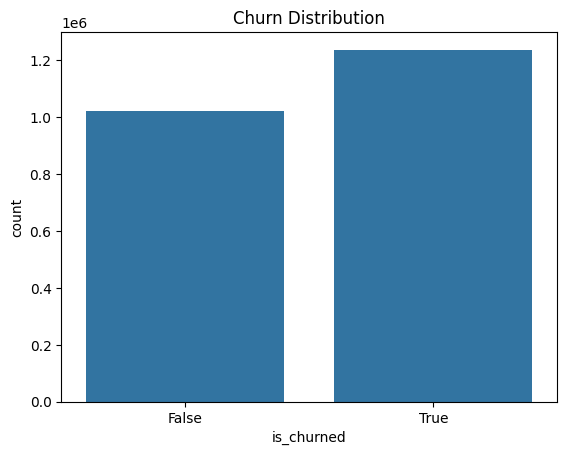

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="is_churned")
plt.title("Churn Distribution")
plt.show()


* * * * *

3️⃣ Behavioral Validation
=========================

### 3.1 Days Since Last Payment (Sanity Check)

Even though churn is defined by this variable, showing separation:

-   Validates classification

-   Demonstrates clean segmentation

Keep it short --- not too deep.

* * * * *

4️⃣ Financial Exposure Analysis
===============================

4.1 Loan Amount (Already Done)
------------------------------

### A) Boxplot

The boxplot shows strong overlap between churned and non-churned groups, indicating that loan amount alone does not provide strong discriminatory power.

Result Medians are similar and the distribution overlap is high.


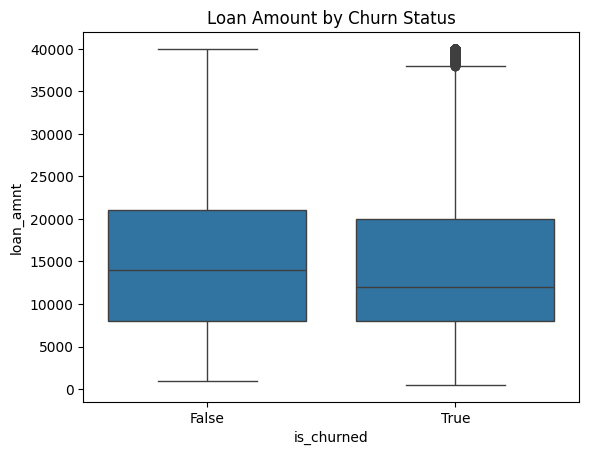

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="is_churned", y="loan_amnt")
plt.title("Loan Amount by Churn Status")
plt.show()


* * * * *

### B) KDE Analysis (Already Done)

The relationship between loan amount and churn is not strictly linear. Lower loan segments exhibit higher churn density, while higher loan amounts demonstrate relatively improved retention. This suggests potential segmentation effects rather than a monotonic relationship.

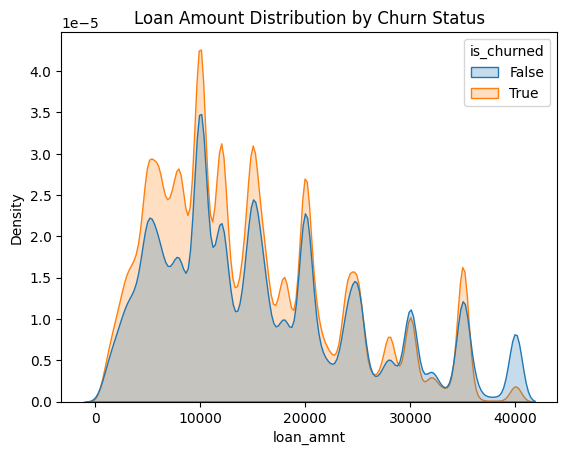

In [14]:
plt.figure()
sns.kdeplot(data=df, x="loan_amnt", hue="is_churned", fill=True)
plt.title("Loan Amount Distribution by Churn Status")
plt.show()




* * * * *

5️⃣ Financial Capacity Analysis
===============================

Now add depth.

5.1 Installment-to-Income Ratio
-------------------------------

Plot:

-   Boxplot or KDE

Goal:\
Determine whether payment burden differentiates churn.

If separation is stronger than loan amount:\
→ This becomes a stronger driver candidate.

* * * * *

5.2 Annual Income
-----------------

Ask:

-   Are churned borrowers systematically lower income?

Again:\
If overlap is strong → document that.

Negative findings are analytical findings.

* * * * *

6️⃣ Risk Profile Analysis
=========================

Now test risk alignment.

6.1 Grade
---------

-   Barplot of churn rate by grade

-   Or stacked percentage

Ask:

-   Does churn increase from A → G?

If yes:\
→ Behavioral churn aligns with credit risk.

If not:\
→ Churn represents a different phenomenon.

* * * * *

6.2 Interest Rate
-----------------

Check:

-   Mean comparison

-   Distribution overlap

Interpret:\
Does pricing risk relate to disengagement?

* * * * *

7️⃣ Lifecycle Analysis
======================

7.1 Loan Age
------------

Key question:\
Is churn biased by exposure time?

This protects you from false conclusions.

* * * * *

7.2 Payment Ratio
-----------------

Does churn occur:

-   Early in repayment?
-   Mid-cycle?
-   Near completion?

This is analytically strong and often overlooked.

* * * * *

8️⃣ Summary of Findings (VERY IMPORTANT)
========================================

This is where your notebook becomes professional.

Create a section:

Key Findings
============

Structure it like:

### 1\. Loan Amount Shows Weak Direct Separation

Despite visible distribution shifts in KDE, boxplot overlap suggests limited standalone predictive power.

### 2\. Financial Burden Shows Moderate Association

Installment-to-income ratio demonstrates stronger separation relative to raw loan size.

### 3\. Risk Grade Partially Aligns With Churn

Lower credit grades exhibit increased churn likelihood, though overlap remains significant.

### 4\. Churn Is Multifactorial

No single variable fully explains churn; interaction effects likely play a major role.